## Actividad 3_10
<div style="border-style:groove;border-width:thin;padding:10px">
Debes usar Random Forests para solucionar el ejercicio de MNIST. Recuerda que con Decision Tree llegamos al 87% de accuracy y con SVC llegamos al 98%. 
    </div>

<div style="border-style:groove;border-width:thin;padding:10px">
A continuación vamos a importar el dataset y a generar los conjuntos X e y.
    </div>

In [37]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [39]:
#df = pd.DataFrame(data=mnist.data, 
#                  columns=mnist.feature_names)

In [40]:
#df.head()

<div style="border-style:groove;border-width:thin;padding:10px">
1. Divide el dataset en el conjunto de entrenamiento y de test.
    </div>

In [41]:
X = mnist.data
y = mnist.target

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((56000, 784), (14000, 784))

<div style="border-style:groove;border-width:thin;padding:10px">
2. Crea un Random Forest con los parámetros que consideres oportuno para solucionar el problema.
    </div>

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor 

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Creamos el modelo
rf_model = RandomForestClassifier(n_estimators=2000 , random_state=42, n_jobs=-1)

# Entrenamos (esto puede tardar unos segundos según tu PC)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=2000, n_jobs=-1, random_state=42)

<div style="border-style:groove;border-width:thin;padding:10px">
3. Genera la predicción (y_pred) con el árbol entrenado y mira la precisión que has conseguido. Módifica los parámetros del árbol en el código del punto 2 para mejorar los resultados.
    </div>

In [45]:
from sklearn.metrics import accuracy_score, classification_report

# Predicciones
y_pred = rf_model.predict(X_test)

# Resultado global
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo: {accuracy * 100:.2f}%")

# Detalle por cada número (0-9)
print(classification_report(y_test, y_pred))

Precisión del modelo: 96.93%
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1381
           1       0.99      0.98      0.99      1575
           2       0.97      0.97      0.97      1398
           3       0.97      0.96      0.96      1428
           4       0.97      0.96      0.97      1365
           5       0.97      0.96      0.97      1263
           6       0.97      0.98      0.98      1375
           7       0.98      0.97      0.97      1459
           8       0.96      0.96      0.96      1365
           9       0.94      0.95      0.95      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



<div style="border-style:groove;border-width:thin;padding:10px">
4. Recorre la muestra de test viendo los datos que son erróneos y muestra la imagen. Evalúa si el resultado es suficientemente bueno.
</div>

Total de errores: 430


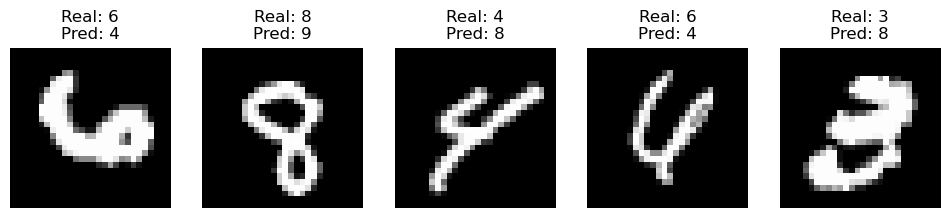

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Buscamos los índices de los errores comparando arrays directamente
# .values convierte a numpy para evitar líos de índices desordenados
errores_idx = np.where(y_pred != y_test.values)[0]

print(f"Total de errores: {len(errores_idx)}")

plt.figure(figsize=(12, 4))
for i, idx in enumerate(errores_idx[:5]):
    plt.subplot(1, 5, i + 1)
    
    # .iloc[idx] accede por POSICIÓN (0, 1, 2...), no por NOMBRE de etiqueta
    imagen = X_test.iloc[idx].values.reshape(28, 28)
    valor_real = y_test.iloc[idx]
    valor_pred = y_pred[idx]
    
    plt.imshow(imagen, cmap='gray')
    plt.title(f"Real: {valor_real}\nPred: {valor_pred}")
    plt.axis('off')
plt.show()

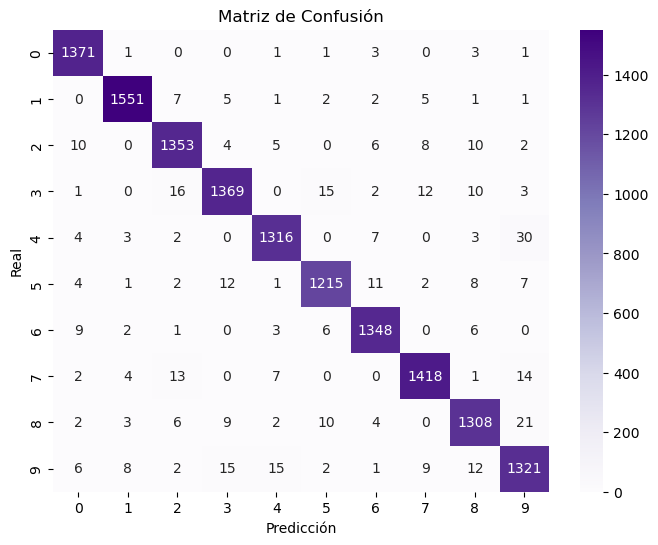

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()